# **Atividade Prática**
<font size=3>

- **Tema:** métodos probabilísticos



### **1. Questão:**
<font size=3>

Com base no *dataset* de [Cogumelos](https://www.kaggle.com/datasets/uciml/mushroom-classification), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Avalie qual tipo de método **_Naive Bayes_** é mais apropriado para realizar a tarefa de classificação dos dados (ver **_notebook_ 9**). **Justifique** sua resposta em uma **célula _markdown_**;
2. Utilize as funções [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) e [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável de atributos (`X`) e alvo (`y`). Utilize [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) caso ache necessário;
3. Treine seu modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) a fim de ajustar seu(s) hiperparâmetro(s);
4. Realize predições e avaliaçãoes do modelo com dados de teste;
5. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
   

In [111]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [113]:
df = pd.read_csv("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


O dataset de cogumelos tem atributos categóricos discretos. Portanto, o melhor método para esse caso é o Categorical Naive Bayes, pois ele modela diretamente probabilidades de categorias.

In [114]:
le = LabelEncoder()
model = CategoricalNB
scaler = StandardScaler()

In [115]:
X = df.drop("class", axis=1)
y = df["class"]

In [116]:
y_encoded = le.fit_transform(y)

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
  test_size=0.2, random_state=42, stratify=y_encoded)


In [118]:
encoder = OrdinalEncoder()

pipe = Pipeline(steps=[
    ("preprocessor", encoder),
    ("model", model())
])
pipe

Pipeline(steps=[('preprocessor', OrdinalEncoder()), ('model', CategoricalNB())])

In [119]:
parametro = {
    "model__alpha": [0.01, 0.1, 0.5, 1.0, 3.0, 5.0]
}

grid = GridSearchCV(
    pipe,
    parametro,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Melhor parâmetro:", grid.best_params_)

Melhor parâmetro: {'model__alpha': 0.01}


In [120]:
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")


              precision    recall  f1-score   support

           e       0.99      0.99      0.99       842
           p       0.99      0.99      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625

Matriz de confusão:
 [[835   7]
 [ 10 773]]
Acurácia: 0.99


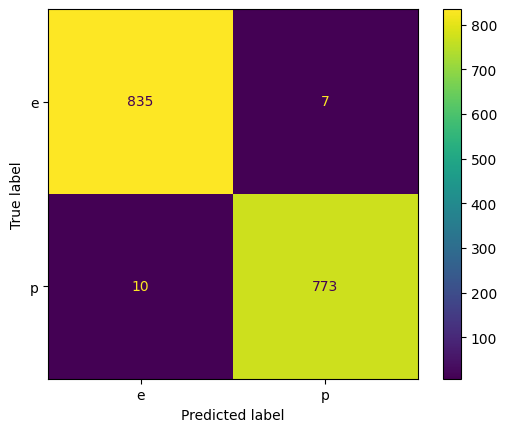

In [121]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()

A matriz de confusão mostra que o modelo teve um bom desempenho com acurácia de 0.99 e apenas 17 erros. No entanto, 10 cogumelos venenosos foram classificados como comestiveis, o que é considerado um grande erro, já que representa um risco à saúde. Logo, eu concluo que o modelo teve um ótimo desempenho na classificação, mas que ainda assim existe um ponto crítico (o falso negativo da classe venenosa) que pode ser melhorado.

### **2. Questão:**
<font size=3>

Com base no *dataset* de [Spams](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Importe os *dataset* atribuindo à variável `encoding = 'latin-1'` na função `read_csv()`, a fim de importar corretamente os dados textuais;
2. Avalie qual tipo de método **_Naive Bayes_** é mais apropriado para realizar a tarefa de classificação dos dados (ver **_notebook_ 9**). **Justifique** sua resposta em uma **célula _markdown_**;
3. Defina os dados de **_spam_** e **_ham_** (não spam) como a variável alvo, e os dados textuais como a variável de atributos;
4. Utilize o [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) para processar os dados textuais e [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo. Utilize [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) caso ache necessário;
5. Treine seu modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) a fim de ajustar seu(s) hiperparâmetro(s);
6. Realize predições e avaliaçãoes do modelo com dados de teste;
7. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
    

In [122]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

In [123]:
df = pd.read_csv("/content/drive/MyDrive/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/spam.csv", encoding='latin-1')
df = df.drop(df.columns[2:], axis=1)
df.columns= ["categoria", "texto"]
df.head()

,categoria,texto
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


O dataset de Spam é composto por mensagens de texto, ou seja, dados que precisam ser transformados em representações numéricas. Com uma vetorização, os dados passam a representar frequências de palavras. Sendo assim, o melhor modelo para esse caso é o Multinomial Naive Bayes, pois ele é projetado para trabalhar com dados de contagem ou frequência, como o número de vezes que uma palavra aparece em um documento.


In [124]:
modelo = MultinomialNB()

In [125]:
X = df["texto"]
y = df["categoria"]

In [126]:
y_encoded = le.fit_transform(y)

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
  test_size=0.2, random_state=42)

In [128]:
vectorizer = CountVectorizer()

pipe = Pipeline(steps=[
    ("preprocessor", vectorizer),
    ("model", modelo)
])
pipe

Pipeline(steps=[('preprocessor', CountVectorizer()),
                ('model', MultinomialNB())])

In [129]:
parametro = {
    "model__alpha": [0.01, 0.1, 0.5, 1.0, 3.0, 5.0]
}

grid = GridSearchCV(
    pipe,
    parametro,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Melhor parâmetro:", grid.best_params_)

Melhor parâmetro: {'model__alpha': 0.1}


In [130]:
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       965
        spam       0.97      0.91      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115

Matriz de confusão:
 [[961   4]
 [ 14 136]]
Acurácia: 0.98


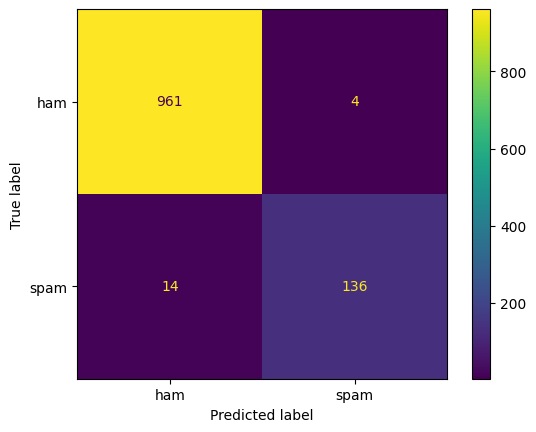

In [131]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()

A matriz de confusão mostra que o modelo teve um bom desempenho com 0.98 de acurácia e apenas 18 erros. Logo, eu concluo que a maioria das mensagens foi corretamente classificada. No entanto, ainda é possível que um email importante e válido seja considerado como spam, visto que há 4 casos de falsos positivos, assim como há 14 casos de falsos negativos, considerando mensagens de spam como mensagens válidas.
